In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
!git clone https://github.com/alispada/computervision-ML4H

Cloning into 'computervision-ML4H'...
remote: Enumerating objects: 22, done.
remote: Counting objects: 100% (22/22), done.
remote: Compressing objects: 100% (13/13), done.
remote: Total 22 (delta 4), reused 14 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (22/22), 1.72 MiB | 2.52 MiB/s, done.
Resolving deltas: 100% (4/4), done.


In [ ]:
#!find /content/drive/MyDrive -name "dataset.zip"
!ls /content/

computervision-ML4H  drive  sample_data


In [ ]:
!mkdir -p /content/computervision-ML4H/data
!unzip "/content/drive/MyDrive/Colab Notebooks/MLproject/dataset.zip" -d /content/computervision-ML4H/data


Output streaming troncato alle ultime 5000 righe.
  inflating: /content/computervision-ML4H/data/dataset/toy_dataset/550.jpg  
  inflating: /content/computervision-ML4H/data/dataset/toy_dataset/5500.jpg  
  inflating: /content/computervision-ML4H/data/dataset/toy_dataset/5501.jpg  
  inflating: /content/computervision-ML4H/data/dataset/toy_dataset/5502.jpg  
  inflating: /content/computervision-ML4H/data/dataset/toy_dataset/5503.jpg  
  inflating: /content/computervision-ML4H/data/dataset/toy_dataset/5504.jpg  
  inflating: /content/computervision-ML4H/data/dataset/toy_dataset/5505.jpg  
  inflating: /content/computervision-ML4H/data/dataset/toy_dataset/5506.jpg  
  inflating: /content/computervision-ML4H/data/dataset/toy_dataset/5507.jpg  
  inflating: /content/computervision-ML4H/data/dataset/toy_dataset/5508.jpg  
  inflating: /content/computervision-ML4H/data/dataset/toy_dataset/5509.jpg  
  inflating: /content/computervision-ML4H/data/dataset/toy_dataset/551.jpg  
  inflating: /co

In [ ]:
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision.models as models
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import Dataset, DataLoader, random_split, WeightedRandomSampler
from PIL import Image
import os, random
import pandas as pd

## Imports for plotting
import matplotlib.pyplot as plt
%matplotlib inline
from matplotlib.colors import to_rgba
import seaborn as sns
sns.set_theme('notebook', style='whitegrid')

## Progress bar
from tqdm.auto import tqdm

In [ ]:
import torch
torch.manual_seed(42) # Setting the seed

print("Using torch", torch.__version__)

Using torch 2.10.0+cu128


In [ ]:
df =  pd.read_csv("dataset/toy_dataset_label.csv", sep="\t", on_bad_lines="skip")

print(df.head(8))

   ID   FILE                  AUTHOR                              BORN-DIED  \
0   1  1.jpg        AACHEN, Hans von        (b. 1552, Köln, d. 1615, Praha)   
1   2  2.jpg        AACHEN, Hans von        (b. 1552, Köln, d. 1615, Praha)   
2   3  3.jpg        AACHEN, Hans von        (b. 1552, Köln, d. 1615, Praha)   
3   4  4.jpg        AACHEN, Hans von        (b. 1552, Köln, d. 1615, Praha)   
4   5  5.jpg        AACHEN, Hans von        (b. 1552, Köln, d. 1615, Praha)   
5   6  6.jpg  AAGAARD, Carl Frederik  (b. 1833, Odense, d. 1895, København)   
6   7  7.jpg  AAGAARD, Carl Frederik  (b. 1833, Odense, d. 1895, København)   
7   8  8.jpg      ABADIA, Juan de la           (active 1470-1490 in Huesca)   

                                TITLE     DATE                    TECHNIQUE  \
0                            Allegory     1598    Oil on copper, 56 x 47 cm   
1            Bacchus, Ceres and Cupid        -  Oil on canvas, 163 x 113 cm   
2                       Joking Couple        -     

In [ ]:
techniques = pd.unique(df['TECHNIQUE'])

print(len(list(techniques)))

21437


In [ ]:
df['TECHNIQUE_CLEAN'] = df['TECHNIQUE'].str.split(',').str[0]

df['TECHNIQUE_CLEAN'] = df['TECHNIQUE_CLEAN'].str.strip().str.lower()

print(len(pd.unique(df['TECHNIQUE_CLEAN'])))

print(f"unique classes: {list(pd.unique(df['TECHNIQUE_CLEAN']))}")

2216
unique classes: ['oil on copper', 'oil on canvas', 'copperplate', 'wood', 'marble', 'oil on panel', 'oil on cardboard', 'silver', 'engraving', 'oil and gouache on paper', 'bronze', 'drawing', 'terracotta', 'photo', 'white marble', 'fresco', 'oil on oak panel', 'cast copper alloy', 'black chalk on vellum', 'stained glass', 'oil on wood', 'oil on oak', 'oil on oak wood', 'oil on paper laid down on board', 'gilt and painted terracotta', 'terracotta with traces of paint', 'glazed terracotta', 'pencil and gouache on paper', 'tempera and leaf on panel', 'tempera on panel', 'oil on wood transferred to canvas', 'engraving. 320 x 170 cm', 'engraving. 280 x 190 mm', 'panel', 'watercolour', 'woodcut', 'tempera and gold on wood', 'tempera on wood', 'black marble', 'oil on canvas : 118 x 92 cm', 'oil on canvas : 86 x 136 cm', 'red and black chalk', 'oil on lead with gold leaf', 'oil on canvas transferred from wood', 'oil on slate', 'watercolour and gum arabic on paper', 'parchment and wood', '

In [ ]:
# Filter techniques with count >= 50
fraction = 1.0
df_sampled = df.sample(frac=fraction, random_state=42).reset_index(drop=True)

technique_counts_sampled = df_sampled['TECHNIQUE_CLEAN'].value_counts()
techniques_filtered = technique_counts_sampled[technique_counts_sampled >= 50].index.tolist()

# Remove '-' if it exists
techniques_filtered = [t for t in techniques_filtered if t != '-']

print(f"Techniques with count >= 50: {techniques_filtered}")
print(f"Number of techniques: {len(techniques_filtered)}")

# Filter dataframe to keep only these techniques
df_filtered = df_sampled[df_sampled['TECHNIQUE_CLEAN'].isin(techniques_filtered)].copy()

# 1. Rimuovi eventuali righe dove il nome del file è mancante (NaN)
df_filtered = df_filtered.dropna(subset=['FILE'])

# 2. Forza tutti i nomi dei file a essere stringhe (previene il TypeError)
df_filtered['FILE'] = df_filtered['FILE'].astype(str)

# 3. Rimuovi righe dove il nome file potrebbe essere una stringa vuota o "nan"
df_filtered = df_filtered[df_filtered['FILE'].str.strip() != ""]
df_filtered = df_filtered[df_filtered['FILE'].str.lower() != "nan"]


print(f"\nOriginal dataset size: {len(df)}")
print(f"Filtered dataset size: {len(df_filtered)}")
print(f"\nFiltered technique counts:\n{df_filtered['TECHNIQUE_CLEAN'].value_counts()}")

Techniques with count >= 50: ['oil on canvas', 'fresco', 'oil on panel', 'photo', 'oil on wood', 'marble', 'tempera on wood', 'bronze', 'tempera on panel', 'oil on oak panel', 'engraving', 'stone', 'panel', 'wood', 'oil on copper', 'woodcut', 'etching', 'oil on oak', 'manuscript', 'mosaic', 'tempera on canvas', 'drawing', 'pen', 'terracotta', 'egg tempera on wood', 'black chalk', 'pen and brown ink', 'glazed terracotta']
Number of techniques: 28

Original dataset size: 42055
Filtered dataset size: 17634

Filtered technique counts:
TECHNIQUE_CLEAN
oil on canvas          6782
fresco                 2133
oil on panel           1517
photo                  1018
oil on wood             942
marble                  918
tempera on wood         557
bronze                  418
tempera on panel        370
oil on oak panel        364
engraving               329
stone                   300
panel                   269
wood                    242
oil on copper           208
woodcut                 152

In [ ]:
def group_techniques_final(tech):
    tech = str(tech).lower()

    # 1. Pittura (Priorità alle tecniche più comuni)
    if 'oil' in tech: return 'oil painting'
    if 'fresco' in tech: return 'fresco'
    if 'tempera' in tech: return 'tempera'
    if 'watercol' in tech or 'water-col' in tech: return 'watercolor'

    # 2. Grafica e Disegno (Unifichiamo engraving, etching, woodcut e chalk)
    if any(x in tech for x in ['engraving', 'etching', 'woodcut']): return 'engraving'
    if any(x in tech for x in ['drawing', 'ink', 'chalk', 'pen', 'graphite', 'pencil']): return 'drawing'

    # 3. Scultura e Materiali Rigidi
    if any(x in tech for x in ['marble', 'stone', 'terracotta', 'clay', 'glazed']): return 'sculpture stone'
    if any(x in tech for x in ['bronze', 'metal', 'gold', 'silver', 'copper']): return 'sculpture metal'
    if any(x in tech for x in ['wood', 'panel', 'oak']):
    # Se nel testo c'è anche "oil" o "tempera", probabilmente è un dipinto, non una scultura
        if any(p in tech for p in ['oil', 'tempera', 'acrylic']):
            return 'pittura_su_tavola'
        return 'wood sculpture'

    # 4. Altro (Vetro, Mosaici, Miniature)
    if 'mosaic' in tech: return 'mosaic'
    if 'glass' in tech: return 'glass art'
    if 'manuscript' in tech or 'illumination' in tech: return 'manuscript'
    if 'photo' in tech: return 'photography'

    return None

df['TECHNIQUE_GROUPED'] = df['TECHNIQUE_CLEAN'].apply(group_techniques_final)
df_filtered['TECHNIQUE_GROUPED'] = df_filtered['TECHNIQUE_CLEAN'].apply(group_techniques_final)

# Remove rows classified as None (unrecognized techniques)
df = df[df['TECHNIQUE_GROUPED'].notna()]
df_filtered = df_filtered[df_filtered['TECHNIQUE_GROUPED'].notna()]

In [ ]:
print(f"Total classes: {len(pd.unique(df_filtered['TECHNIQUE_GROUPED']))}")
print(f"Classes: {sorted(list(pd.unique(df_filtered['TECHNIQUE_GROUPED'])))}")
print(f"\nClass distribution:\n{df_filtered['TECHNIQUE_GROUPED'].value_counts()}")

Total classes: 11
Classes: ['drawing', 'engraving', 'fresco', 'manuscript', 'mosaic', 'oil painting', 'photography', 'sculpture metal', 'sculpture stone', 'tempera', 'wood sculpture']

Class distribution:
TECHNIQUE_GROUPED
oil painting       9931
fresco             2133
sculpture stone    1349
tempera            1103
photography        1018
engraving           602
wood sculpture      511
sculpture metal     418
drawing             337
manuscript          117
mosaic              115
Name: count, dtype: int64


In [ ]:
import torch
import torch.nn as nn
import numpy as np
# 1. Calcola class weights con Smoothing (Square Root)
# Lo smoothing serve a non rendere i pesi eccessivamente punitivi per le classi comuni
class_counts = df_filtered['TECHNIQUE_GROUPED'].value_counts()
total_samples = len(df_filtered)
num_classes = len(df_filtered['TECHNIQUE_GROUPED'].unique())

class_weights = {}
for technique in df_filtered['TECHNIQUE_GROUPED'].unique():
    count = class_counts.get(technique, 0)
    # Formula con radice quadrata per bilanciare senza esagerare
    weight = np.sqrt(total_samples / (num_classes * count)) if count > 0 else 0
    class_weights[technique] = weight

print("Pesi delle Classi (con Smoothing applicato):")
for technique, weight in sorted(class_weights.items(), key=lambda x: x[1], reverse=True):
    print(f"  {technique}: {weight:.4f}")

# 2. Mapping Label <-> Indice (Ordinamento alfabetico per coerenza)
techniques_grouped = sorted(df_filtered['TECHNIQUE_GROUPED'].unique())
class_to_idx = {technique: idx for idx, technique in enumerate(techniques_grouped)}
idx_to_class = {idx: technique for technique, idx in class_to_idx.items()}

print("\nMapping Classi -> Indici:")
print(class_to_idx)

# 3. Preparazione Tensore per la Loss Function
# Creiamo il tensore seguendo l'ordine esatto degli indici (0, 1, 2...)
weights_ordered = [class_weights[t] for t in techniques_grouped]
class_weights_tensor = torch.tensor(weights_ordered, dtype=torch.float32)

# Spostiamo il tensore sul device (GPU se disponibile)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
class_weights_tensor = class_weights_tensor.to(device)

# Definizione del Criterio di Errore
#criterion = nn.CrossEntropyLoss(weight=class_weights_tensor.to(device), label_smoothing=0.1)

print(f"\n✓ Configurazione completata per {device}:")
#print(f"  Usa 'criterion' nel tuo ciclo di training.")


Pesi delle Classi (con Smoothing applicato):
  mosaic: 3.7336
  manuscript: 3.7016
  drawing: 2.1810
  sculpture metal: 1.9584
  wood sculpture: 1.7712
  engraving: 1.6319
  photography: 1.2549
  tempera: 1.2056
  sculpture stone: 1.0901
  fresco: 0.8669
  oil painting: 0.4018

Mapping Classi -> Indici:
{'drawing': 0, 'engraving': 1, 'fresco': 2, 'manuscript': 3, 'mosaic': 4, 'oil painting': 5, 'photography': 6, 'sculpture metal': 7, 'sculpture stone': 8, 'tempera': 9, 'wood sculpture': 10}

✓ Configurazione completata per cuda:
  Usa 'criterion' nel tuo ciclo di training.


In [ ]:
# === Custom Dataset Class ===
class CustomImageDataset(Dataset):
    def __init__(self, dataframe, class_to_idx, img_dir='data/dataset/toy_dataset', transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.class_to_idx = class_to_idx
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        img_filename = self.dataframe.iloc[index]['FILE']
        img_path = os.path.join(self.img_dir, img_filename)

        try:
            image = Image.open(img_path).convert("RGB")
        except Exception as e:
            # Silenziamo l'errore o usiamo un placeholder
            image = Image.new('RGB', (224, 224))

        label_str = self.dataframe.iloc[index]['TECHNIQUE_GROUPED']
        label = self.class_to_idx[label_str]

        if self.transform:
            image = self.transform(image)

        return image, label

# === Trasformazioni ===
transform_train =transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.5, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),

    # Opzionale ma consigliato per le tecniche artistiche (es. disegni vs foto)
    transforms.RandomGrayscale(p=0.1),

    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

transform_val = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
# === Split Dataset ===
train_size = int(0.8 * len(df_filtered))
val_size = len(df_filtered) - train_size
train_df_split = df_filtered.sample(n=train_size, random_state=42)
val_df_split = df_filtered.drop(train_df_split.index).reset_index(drop=True)
train_df_split = train_df_split.reset_index(drop=True)

# === Crea i dataset ===
# NOTA: Assicurati che 'img_dir' punti alla cartella corretta su Colab (es. '/content/UNIBO_MachineLearning/dataset/...')
train_dataset = CustomImageDataset(
    dataframe=train_df_split,
    class_to_idx=class_to_idx,
    img_dir='data/dataset/toy_dataset',
    transform=transform_train
)

val_dataset = CustomImageDataset(
    dataframe=val_df_split,
    class_to_idx=class_to_idx,
    img_dir='data/dataset/toy_dataset',
    transform=transform_val
)

# === Crea i DataLoader ===
batch_size = 64

# Calcolo pesi per il Sampler
counts = train_df_split['TECHNIQUE_GROUPED'].value_counts()
weights_per_class = {cls: 1.0/count for cls, count in counts.items()}
train_weights = [weights_per_class[label] for label in train_df_split['TECHNIQUE_GROUPED']]
train_sampler = WeightedRandomSampler(train_weights, num_samples=len(train_weights), replacement=True)

# DataLoader (aggiunto num_workers per velocità su Colab)
train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=train_sampler, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"✓ Dataset pronti!")
print(f"Train: {len(train_dataset)} immagini | Val: {len(val_dataset)} immagini")

✓ Dataset pronti!
Train: 14107 immagini | Val: 3527 immagini


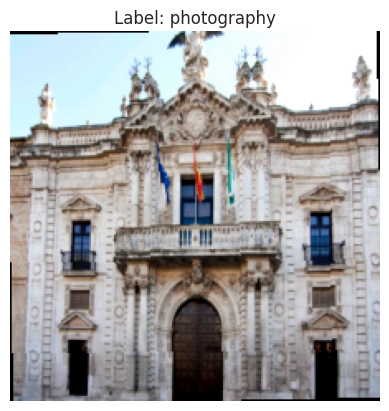

In [ ]:
# === Visualizza alcune immagini con le loro true label ===
# Funzione semplificata per mostrare un'immagine
import matplotlib.pyplot as plt
import torch

# Questo comando assicura che i grafici vengano mostrati sotto la cella
%matplotlib inline

def plot_example_image(dataset, index):
    image, label = dataset[index]

    # Denormalizza l'immagine (semplice come nell'esempio)
    image = image * torch.tensor([0.229, 0.224, 0.225]).unsqueeze(1).unsqueeze(2) + torch.tensor([0.485, 0.456, 0.406]).unsqueeze(1).unsqueeze(2)

    # Converti in numpy array per il plotting
    image = image.permute(1, 2, 0).numpy()  # Da CxHxW a HxWxC
    image = image.clip(0, 1)  # Assicura valori tra 0 e 1

    # Ottieni la stringa del label
    label_str = idx_to_class[label]  # Usa il mapping globale

    # Mostra l'immagine
    plt.imshow(image)
    plt.title(f"Label: {label_str}")
    plt.axis('off')
    plt.show()

# Mostra alcune immagini di esempio
plot_example_image(train_dataset, index=2)

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
from tqdm.auto import tqdm

# === 1. CONFIGURAZIONE PERCORSI E DIRECTORY ===
# Percorso di destinazione su Google Drive
drive_model_path = "/content/drive/MyDrive/Colab Notebooks/MLproject/densenet121.tar"

# Creazione della directory se non esistente
os.makedirs(os.path.dirname(drive_model_path), exist_ok=True)

# === 2. DEFINIZIONE ARCHITETTURA MODELLO ===
# Caricamento DenseNet-121 con pesi pre-addestrati
model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)

# Congelamento dei parametri iniziali (Transfer Learning)
for param in model.parameters():
    param.requires_grad = False

# Sblocco dell'ultimo blocco denso e dello strato di normalizzazione per il fine-tuning
for param in model.features.denseblock4.parameters():
    param.requires_grad = True
for param in model.features.norm5.parameters():
    param.requires_grad = True

# Sostituzione del classificatore finale
num_features = model.classifier.in_features
num_classes = len(class_to_idx)
model.classifier = nn.Sequential(
    nn.Dropout(p=0.7),
    nn.Linear(num_features, num_classes)
)

# Configurazione del dispositivo di calcolo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Definizione della funzione di perdita e dell'ottimizzatore
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor, label_smoothing=0.1)
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.0001,
    weight_decay=1e-3
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',    # Monitora la Val Loss (vogliamo che sia minima)
    factor=0.5,    # Dimezza il LR quando attivato
    patience=2     # Aspetta 2 epoche di "stallo" prima di intervenire
)

# === 3. FUNZIONE DI ADDESTRAMENTO CON EARLY STOPPING ===
def train_model(model, train_loader, val_loader, criterion, optimizer, save_path, num_epochs=20, patience=5):
    best_val_acc = 0.0
    epochs_no_improve = 0
    best_model_state = None

    for epoch in range(num_epochs):
        # Fase di Training
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]")
        for images, labels in train_pbar:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            train_pbar.set_postfix({
                'Loss': f'{running_loss/len(train_pbar):.4f}',
                'Acc': f'{100 * correct / total:.2f}%'
            })

        train_loss = running_loss / len(train_loader)
        train_accuracy = 100 * correct / total

        # Fase di Validazione
        model.eval()
        torch.cuda.empty_cache() # Libera la memoria video non utilizzata
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            val_pbar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]", leave=False)
            for images, labels in val_pbar:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_loss /= len(val_loader)
        val_accuracy = 100 * val_correct / val_total

        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]['lr']

        print(f"\nFine Epoca [{epoch+1}/{num_epochs}]:")
        print(f"   Train Loss: {train_loss:.4f} | Acc: {train_accuracy:.2f}%")
        print(f"   Val Loss: {val_loss:.4f}   | Acc: {val_accuracy:.2f}%")

        # Monitoraggio miglioramenti e salvataggio
        if val_accuracy > best_val_acc:
            best_val_acc = val_accuracy
            epochs_no_improve = 0
            best_model_state = model.state_dict()

            torch.save(best_model_state, save_path)
            print(f"Modello aggiornato e salvato su Drive.")
        else:
            epochs_no_improve += 1
            print(f"Nessun miglioramento registrato ({epochs_no_improve}/{patience}).")

        if epochs_no_improve >= patience:
            print(f"Interruzione anticipata (Early Stopping) attivata.")
            break

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    return model

# === 4. ESECUZIONE ===
model = train_model(model, train_loader, val_loader, criterion, optimizer, drive_model_path)

Epoch 1/20 [Train]:   0%|          | 0/441 [00:00<?, ?it/s]

Epoch 1/20 [Val]:   0%|          | 0/111 [00:00<?, ?it/s]


Fine Epoca [1/20]:
   Train Loss: 0.9783 | Acc: 55.33%
   Val Loss: 1.1297   | Acc: 37.34%
Modello aggiornato e salvato su Drive.


Epoch 2/20 [Train]:   0%|          | 0/441 [00:00<?, ?it/s]

Epoch 2/20 [Val]:   0%|          | 0/111 [00:00<?, ?it/s]

...

Epoch 19/20 [Val]:   0%|          | 0/111 [00:00<?, ?it/s]


Fine Epoca [19/20]:
   Train Loss: 0.0396 | Acc: 97.07%
   Val Loss: 0.7490   | Acc: 80.41%
Nessun miglioramento registrato (4/5).


Epoch 20/20 [Train]:   0%|          | 0/441 [00:00<?, ?it/s]

Epoch 20/20 [Val]:   0%|          | 0/111 [00:00<?, ?it/s]


Fine Epoca [20/20]:
   Train Loss: 0.0341 | Acc: 97.66%
   Val Loss: 0.7315   | Acc: 80.95%
Nessun miglioramento registrato (5/5).
Interruzione anticipata (Early Stopping) attivata.
